The questions are:
#1. How much does each goalie contribute to their teams wins?
#2. Rank them, are there any trends or outliers?
#3. What stats are most important to goalies success?


In [210]:
#load in data and evaluate columns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

data = pd.read_csv('goalie_data.csv')

#check columns
data.columns

Index(['playerId', 'season', 'name', 'team', 'position', 'situation',
       'games_played', 'icetime', 'xGoals', 'goals', 'unblocked_shot_attempts',
       'xRebounds', 'rebounds', 'xFreeze', 'freeze', 'xOnGoal', 'ongoal',
       'xPlayStopped', 'playStopped', 'xPlayContinuedInZone',
       'playContinuedInZone', 'xPlayContinuedOutsideZone',
       'playContinuedOutsideZone', 'flurryAdjustedxGoals', 'lowDangerShots',
       'mediumDangerShots', 'highDangerShots', 'lowDangerxGoals',
       'mediumDangerxGoals', 'highDangerxGoals', 'lowDangerGoals',
       'mediumDangerGoals', 'highDangerGoals', 'blocked_shot_attempts',
       'penalityMinutes', 'penalties'],
      dtype='object')

In [211]:
#drop unnecessary columns

#all expected outcome columns
expected = data.loc[:, data.columns.str.contains('x')]
data = data.drop(columns=expected.columns)

#other unnecessary columns
data = data.drop(columns=['season',
                          'position',
                          'playStopped',
                          'playContinuedInZone',
                          'playContinuedOutsideZone',
                          'blocked_shot_attempts',
                          'penalityMinutes',
                          'penalties'])

#view remaining columns
data.columns


Index(['playerId', 'name', 'team', 'situation', 'games_played', 'icetime',
       'goals', 'unblocked_shot_attempts', 'rebounds', 'freeze', 'ongoal',
       'lowDangerShots', 'mediumDangerShots', 'highDangerShots',
       'lowDangerGoals', 'mediumDangerGoals', 'highDangerGoals'],
      dtype='object')

In [212]:
#format columns to be more readable
data = data.rename(columns={'icetime': 'icetime_seconds',
                            'goals': 'goals_allowed',
                            'ongoal': 'shots_on_goal',
                            'lowDangerShots': 'low_danger_shots',
                            'mediumDangerShots': 'medium_danger_shots',
                            'highDangerShots': 'high_danger_shots',
                            'lowDangerGoals': 'low_danger_goals',
                            'mediumDangerGoals': 'medium_danger_goals',
                            'highDangerGoals': 'high_danger_goals'})


In [213]:
#change columns to correct data types
data['playerId'] = data['playerId'].astype(str)
data['situation'] = data['situation'].astype('category')
data.info()

#playerid = id of each goalie since each goalie has multiple senerios, used as index
#games_played = number of games played in the season
#icetime = total time on ice in seconds
#goals_allowed = total goals allowed in the season
#unblocked_shot_attempts = total shots taken by opposing team that were not blocked by the goalies teammate
#rebounds = total rebounds allowed by the goalie
#freeze = times the goalie froze the puck for a stoppage in play
#shots_on_goal = shots faced by goalie that were on target to hit the net
#low_danger_shots = shots faced that had a low chance of scoring
#medium_danger_shots = shots faced that had a medium chance of scoring
#high_danger_shots = shots faced that had a high chance of scoring
#low_danger_goals = goals allowed that had a low chance of scoring
#medium_danger_goals = goals allowed that had a medium chance of scoring
#high_danger_goals = goals allowed that had a high chance of scoring

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515 entries, 0 to 514
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   playerId                 515 non-null    object  
 1   name                     515 non-null    object  
 2   team                     515 non-null    object  
 3   situation                515 non-null    category
 4   games_played             515 non-null    int64   
 5   icetime_seconds          515 non-null    int64   
 6   goals_allowed            515 non-null    int64   
 7   unblocked_shot_attempts  515 non-null    int64   
 8   rebounds                 515 non-null    int64   
 9   freeze                   515 non-null    int64   
 10  shots_on_goal            515 non-null    int64   
 11  low_danger_shots         515 non-null    int64   
 12  medium_danger_shots      515 non-null    int64   
 13  high_danger_shots        515 non-null    int64   
 14  low_danger

In [214]:
#set playerId as index
data.set_index('playerId')

,name,team,situation,games_played,icetime_seconds,goals_allowed,unblocked_shot_attempts,rebounds,freeze,shots_on_goal,low_danger_shots,medium_danger_shots,high_danger_shots,low_danger_goals,medium_danger_goals,high_danger_goals
playerId,,,,,,,,,,,,,,,,
8478048,Igor Shesterkin,NYR,other,61,4629,13,141,12,9,80,60,31,21,4,1,8
8478048,Igor Shesterkin,NYR,all,61,210308,167,3589,206,326,1751,1869,513,228,56,64,47
8478048,Igor Shesterkin,NYR,5on5,61,172568,118,2899,152,267,1385,1539,395,149,46,52,20
8478048,Igor Shesterkin,NYR,4on5,61,18561,31,483,39,49,249,234,76,54,4,9,18
8478048,Igor Shesterkin,NYR,5on4,61,14550,5,65,3,1,37,35,11,4,2,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8480045,Ukko-Pekka Luukkonen,BUF,other,55,6626,19,197,11,11,96,80,38,20,6,6,7
8480045,Ukko-Pekka Luukkonen,BUF,all,55,190333,169,3115,180,293,1490,1670,430,172,58,62,49
8480045,Ukko-Pekka Luukkonen,BUF,5on5,55,155261,116,2471,145,245,1157,1342,337,105,50,47,19


In [215]:
#check for missing values
data.isna().any()
#no missing values so we're good here

playerId                   False
name                       False
team                       False
situation                  False
games_played               False
icetime_seconds            False
goals_allowed              False
unblocked_shot_attempts    False
rebounds                   False
freeze                     False
shots_on_goal              False
low_danger_shots           False
medium_danger_shots        False
high_danger_shots          False
low_danger_goals           False
medium_danger_goals        False
high_danger_goals          False
dtype: bool

In [216]:
#any duplicate rows
any(data.duplicated())
#no duplicate rows so we're good here

False

In [217]:
#import win stats
win_data = pd.read_csv('goalie_wins.csv')
#drop unnecessary columns (it wont match with other data if we keep player_id)
win_data = win_data.drop(columns=['player_id'])
#change W to wins
win_data = win_data.rename(columns={'W': 'wins'})

In [218]:
#check for missing values
win_data.isna().any()

Player    False
wins      False
dtype: bool

In [219]:
#check datatypes
win_data.dtypes

Player    object
wins       int64
dtype: object

In [220]:
#join with data
data = data.join(win_data.set_index('Player'), on='name')
#if no win data then set to 0 since they didnt win any games
data['wins'] = data['wins'].fillna(0)
data.head(3)

,playerId,name,team,situation,games_played,icetime_seconds,goals_allowed,unblocked_shot_attempts,rebounds,freeze,shots_on_goal,low_danger_shots,medium_danger_shots,high_danger_shots,low_danger_goals,medium_danger_goals,high_danger_goals,wins
0,8478048,Igor Shesterkin,NYR,other,61,4629,13,141,12,9,80,60,31,21,4,1,8,27.0
1,8478048,Igor Shesterkin,NYR,all,61,210308,167,3589,206,326,1751,1869,513,228,56,64,47,27.0
2,8478048,Igor Shesterkin,NYR,5on5,61,172568,118,2899,152,267,1385,1539,395,149,46,52,20,27.0


In [221]:
#calculate danger level saves
for quality in ['low', 'medium', 'high']:
    data[quality+'_danger_saves'] = data[quality+'_danger_shots'] - data[quality+'_danger_goals']

data.columns

Index(['playerId', 'name', 'team', 'situation', 'games_played',
       'icetime_seconds', 'goals_allowed', 'unblocked_shot_attempts',
       'rebounds', 'freeze', 'shots_on_goal', 'low_danger_shots',
       'medium_danger_shots', 'high_danger_shots', 'low_danger_goals',
       'medium_danger_goals', 'high_danger_goals', 'wins', 'low_danger_saves',
       'medium_danger_saves', 'high_danger_saves'],
      dtype='object')

In [222]:
#check games played for bins model
data['games_played'].describe()

count    515.000000
mean      26.834951
std       20.551301
min        1.000000
25%        6.000000
50%       26.000000
75%       47.000000
max       63.000000
Name: games_played, dtype: float64

In [223]:
#put goalies in bins based on games played
bins = [0, 20, 40, 50, 60, 82]
role = ['callup', 'backup', 'fringe_starter', 'starter', 'elite']

data['workload'] = pd.cut(data['games_played'], bins, labels=role)

#since each situation has different games played and we only need it for all I will make all others null
data.loc[data['situation'] != 'all', 'workload'] = None

#check distribution of goalies in each bin
print(data['playerId'].nunique())
data['workload'].value_counts()
#these values are equal

103


workload
callup            44
backup            29
starter           15
fringe_starter    10
elite              5
Name: count, dtype: int64

In [224]:
#calculate save percentage for each danger level
for quality in ['low', 'medium', 'high']:
    data[quality+'_danger_save_percentage'] = data[quality+'_danger_saves'] / data[quality+'_danger_shots']

In [225]:
#find the league average save percentage for each danger level
#this will be used to assign values for the wins model
danger_percentages = pd.DataFrame([data['low_danger_save_percentage'].mean(),
                                data['medium_danger_save_percentage'].mean(),
                                data['high_danger_save_percentage'].mean(),], 
                                index=['low', 'medium', 'high'], columns=['save_percentage'])

#the inverse of each will the value a save from this disance has in the wins model
danger_save_values =  1 - danger_percentages
danger_save_values.rename(columns={'save_percentage': 'save_value'}, inplace=True)

#for goals from each quality will will give low the save percent value and make them relative to that based on how much less liekly the save is
danger_goal_values = pd.DataFrame([-1*danger_percentages.loc['low', 'save_percentage'], 
                                float(-1*danger_percentages.loc['low', 'save_percentage']*(danger_save_values.loc['low'] / danger_save_values.loc['medium'])), 
                                float(-1*danger_percentages.loc['low', 'save_percentage']*(danger_save_values.loc['low'] / danger_save_values.loc['high']))],
                                index=['low', 'medium', 'high'], columns=['goal_value'])

values = pd.concat([danger_save_values, danger_goal_values], axis=1)
values

C:\Users\owenm\AppData\Local\Temp\ipykernel_16160\1752745109.py:14: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(-1*danger_percentages.loc['low', 'save_percentage']*(danger_save_values.loc['low'] / danger_save_values.loc['medium'])),
C:\Users\owenm\AppData\Local\Temp\ipykernel_16160\1752745109.py:15: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(-1*danger_percentages.loc['low', 'save_percentage']*(danger_save_values.loc['low'] / danger_save_values.loc['high']))],


,save_value,goal_value
low,0.045578,-0.954422
medium,0.148811,-0.292321
high,0.247952,-0.175440


In [226]:
#on average 11.8% of rebounds are scored so the negative value for rebounds will -0.118
#add rebound value as column
values['rebound_value'] = np.nan
values.loc['rebound'] = [np.nan, np.nan, -0.118]

values


,save_value,goal_value,rebound_value
low,0.045578,-0.954422,NaN
medium,0.148811,-0.292321,NaN
high,0.247952,-0.175440,NaN
rebound,NaN,NaN,-0.118


In [227]:
#freeze value is inverse of rebounds so 0.118, but then minus low save value as to not double count value of saves as freezes
values['freeze_value'] = np.nan
values.loc['freeze'] = [np.nan, np.nan, np.nan, 0.118 - values.loc['low', 'save_value']]

values

,save_value,goal_value,rebound_value,freeze_value
low,0.045578,-0.954422,NaN,NaN
medium,0.148811,-0.292321,NaN,NaN
high,0.247952,-0.175440,NaN,NaN
rebound,NaN,NaN,-0.118,NaN
freeze,NaN,NaN,NaN,0.072422


In [228]:
#now make a dataframe with the multipliers for the situations model
#fill every value with nan for now and then we can fill in the values after we do the analysis to determine the multipliers for each situation
situation_values = pd.DataFrame(np.nan, index=['5on5','5on4','4on5','other'], columns=['low_danger_goals','medium_danger_goals','high_danger_goals',
                                                                                                 'low_danger_saves','medium_danger_saves','high_danger_saves',
                                                                                                 'rebound', 'freeze'])
#assign multipliers
#did 20% increments since avg pp effectiveness is about 20%
situation_values.loc['5on5'] = [1, 1, 1, 1, 1, 1, 1, 1]
situation_values.loc['5on4'] = [1.2,1.2,1.2,0.8,0.8,0.8,1.2,0.8]
situation_values.loc['4on5'] = [0.8,0.8,0.8,1.2,1.2,1.2,0.8,1.2]
situation_values.loc['other'] = [1, 1, 1, 1, 1, 1, 1, 1]

situation_values

,low_danger_goals,medium_danger_goals,high_danger_goals,low_danger_saves,medium_danger_saves,high_danger_saves,rebound,freeze
5on5,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
5on4,1.2,1.2,1.2,0.8,0.8,0.8,1.2,0.8
4on5,0.8,0.8,0.8,1.2,1.2,1.2,0.8,1.2
other,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [229]:
data.dtypes

playerId                           object
name                               object
team                               object
situation                        category
games_played                        int64
icetime_seconds                     int64
goals_allowed                       int64
unblocked_shot_attempts             int64
rebounds                            int64
freeze                              int64
shots_on_goal                       int64
low_danger_shots                    int64
medium_danger_shots                 int64
high_danger_shots                   int64
low_danger_goals                    int64
medium_danger_goals                 int64
high_danger_goals                   int64
wins                              float64
low_danger_saves                    int64
medium_danger_saves                 int64
high_danger_saves                   int64
workload                         category
low_danger_save_percentage        float64
medium_danger_save_percentage     

In [230]:
#pivot the table so there is a row for each player and situation for column and every other column is the value for that situation
data = data.pivot(index=['playerId', 'name', 'team'], columns='situation', values=['wins', 'games_played','icetime_seconds','goals_allowed',
                                                                               'unblocked_shot_attempts','rebounds','freeze','shots_on_goal','low_danger_shots',
                                                                               'medium_danger_shots','high_danger_shots','low_danger_goals','medium_danger_goals',
                                                                               'high_danger_goals','low_danger_saves','medium_danger_saves','high_danger_saves',
                                                                               'low_danger_save_percentage','medium_danger_save_percentage','high_danger_save_percentage',
                                                                               'workload'])
#change columns back to floats except for workload
for col in data.columns:
    if col[0] != 'workload':
        data[col] = data[col].astype(float)
data

wins                         games_played  \
situation                        4on5  5on4  5on5   all other         4on5   
playerId name              team                                              
8470594  Marc-Andre Fleury MIN   14.0  14.0  14.0  14.0  14.0         26.0   
8471734  Jonathan Quick    NYR   11.0  11.0  11.0  11.0  11.0         24.0   
8473503  James Reimer      BUF   10.0  10.0  10.0  10.0  10.0         24.0   
8473575  Semyon Varlamov   NYI    3.0   3.0   3.0   3.0   3.0         10.0   
8474593  Jacob Markstrom   NJD   26.0  26.0  26.0  26.0  26.0         49.0   
...                               ...   ...   ...   ...   ...          ...   
8483710  Dennis Hildeby    TOR    3.0   3.0   3.0   3.0   3.0          6.0   
8484268  Nikita Tolopilo   VAN    1.0   1.0   1.0   1.0   1.0          2.0   
8484293  Yaniv Perets      CAR    0.0   0.0   0.0   0.0   0.0          1.0   
8484312  Georgi Romanov    SJS    0.0   0.0   0.0   0.0   0.0          8.0   
8484910  Victor Ostman     SEA    0.0   0.0   0.0   0.0   0.0          1.0   

                                                         ...  \
situation                        5on4  5on5   all other  ...   
playerId name              team                          ...   
8470594  Marc-Andre Fleury MIN   26.0  26.0  26.0  26.0  ...   
8471734  Jonathan Quick    NYR   24.0  24.0  24.0  24.0  ...   
8473503  James Reimer      BUF   24.0  24.0  24.0  24.0  ...   
8473575  Semyon Varlamov   NYI   10.0  10.0  10.0  10.0  ...   
8474593  Jacob Markstrom   NJD   49.0  49.0  49.0  49.0  ...   
...                               ...   ...   ...   ...  ...   
8483710  Dennis Hildeby    TOR    6.0   6.0   6.0   6.0  ...   
8484268  Nikita Tolopilo   VAN    2.0   2.0   2.0   2.0  ...   
8484293  Yaniv Perets      CAR    1.0   1.0   1.0   1.0  ...   
8484312  Georgi Romanov    SJS    8.0   8.0   8.0   8.0  ...   
8484910  Victor Ostman     SEA    1.0   1.0   1.0   1.0  ...   

                                high_danger_save_percentage                  \
situation                                              4on5  5on4      5on5   
playerId name              team                                               
8470594  Marc-Andre Fleury MIN                     0.307692  1.00  0.866667   
8471734  Jonathan Quick    NYR                     0.461538  1.00  0.913043   
8473503  James Reimer      BUF                     0.687500  0.75  0.791045   
8473575  Semyon Varlamov   NYI                     0.000000   NaN  0.833333   
8474593  Jacob Markstrom   NJD                     0.789474  1.00  0.857143   
...                                                     ...   ...       ...   
8483710  Dennis Hildeby    TOR                     0.000000  0.00  0.727273   
8484268  Nikita Tolopilo   VAN                     0.000000   NaN       NaN   
8484293  Yaniv Perets      CAR                     1.000000   NaN       NaN   
8484312  Georgi Romanov    SJS                     0.625000   NaN  0.769231   
8484910  Victor Ostman     SEA                          NaN   NaN  1.000000   

                                                    workload            \
situation                             all     other     4on5 5on4 5on5   
playerId name              team                                          
8470594  Marc-Andre Fleury MIN   0.725490  0.833333      NaN  NaN  NaN   
8471734  Jonathan Quick    NYR   0.790323       NaN      NaN  NaN  NaN   
8473503  James Reimer      BUF   0.787879  0.916667      NaN  NaN  NaN   
8473575  Semyon Varlamov   NYI   0.733333       NaN      NaN  NaN  NaN   
8474593  Jacob Markstrom   NJD   0.830645  0.769231      NaN  NaN  NaN   
...                                   ...       ...      ...  ...  ...   
8483710  Dennis Hildeby    TOR   0.642857  1.000000      NaN  NaN  NaN   
8484268  Nikita Tolopilo   VAN   0.000000       NaN      NaN  NaN  NaN   
8484293  Yaniv Perets      CAR   1.000000       NaN      NaN  NaN  NaN   
8484312  Georgi Romanov    SJS   0.714286       

In [231]:
#calculate the goals attributed for each goalie using the values and situation multipliers
for playerId in data.index:
    for situation in ['5on5', '5on4', '4on5', 'other']:
        data.loc[playerId, ('goals_attributed', situation)] = (
            (data.loc[playerId, ('low_danger_saves', situation)] * values.loc['low', 'save_value'] * situation_values.loc[situation, 'low_danger_saves'])+
            (data.loc[playerId, ('medium_danger_saves', situation)] * values.loc['medium', 'save_value'] * situation_values.loc[situation, 'medium_danger_saves']) + 
            (data.loc[playerId, ('high_danger_saves', situation)] * values.loc['high', 'save_value'] * situation_values.loc[situation, 'high_danger_saves']) + 
            (data.loc[playerId, ('low_danger_goals', situation)] * values.loc['low', 'goal_value'] * situation_values.loc[situation, 'low_danger_goals']) + 
            (data.loc[playerId, ('medium_danger_goals', situation)] * values.loc['medium', 'goal_value'] * situation_values.loc[situation, 'medium_danger_goals']) + 
            (data.loc[playerId, ('high_danger_goals', situation)] * values.loc['high', 'goal_value'] * situation_values.loc[situation, 'high_danger_goals']) + 
            (data.loc[playerId, ('rebounds', situation)] * values.loc['rebound', 'rebound_value'] * situation_values.loc[situation, 'rebound']) + 
            (data.loc[playerId, ('freeze', situation)] * values.loc['freeze', 'freeze_value'] * situation_values.loc[situation, 'freeze']))
    data[('goals_attributed', 'total')] = (
        data[('goals_attributed', '5on5')] +
        data[('goals_attributed', '5on4')] +
        data[('goals_attributed', '4on5')] +
        data[('goals_attributed', 'other')])

#divide by 6, since that is estimated number of goals per win, to get wins attributed
data['wins_attributed'] = data[('goals_attributed', 'total')] / 6
#per game wins attributed
data['wins_attributed_per_game'] = data['wins_attributed'] / data[('games_played', 'all')]

C:\Users\owenm\AppData\Local\Temp\ipykernel_16160\1657648065.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data.loc[playerId, ('goals_attributed', situation)] = (
C:\Users\owenm\AppData\Local\Temp\ipykernel_16160\1657648065.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data.loc[playerId, ('goals_attributed', situation)] = (
C:\Users\owenm\AppData\Local\Temp\ipykernel_16160\1657648065.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has p

In [232]:
#average per goalie
data['wins_attributed'].mean()

np.float64(7.265383857143997)

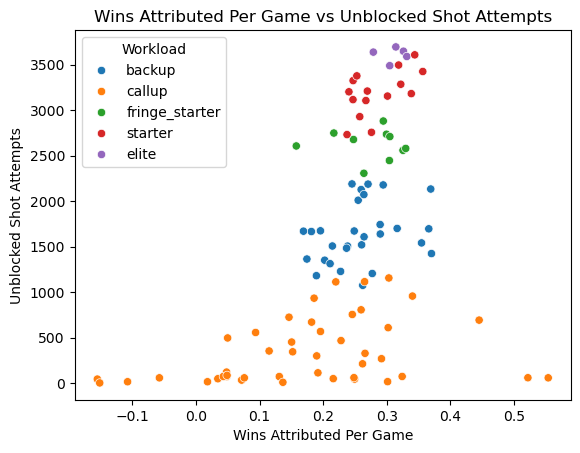

In [233]:
#chart for wins attributed per game by how many unblocked shots the goalie faces
sb.scatterplot(data=data,
               x=data['wins_attributed_per_game'],
               y=data[('unblocked_shot_attempts', 'all')],
               hue=data[('workload', 'all')])

plt.title('Wins Attributed Per Game vs Unblocked Shot Attempts')
plt.xlabel('Wins Attributed Per Game')
plt.ylabel('Unblocked Shot Attempts')
plt.legend(title='Workload')
plt.show()

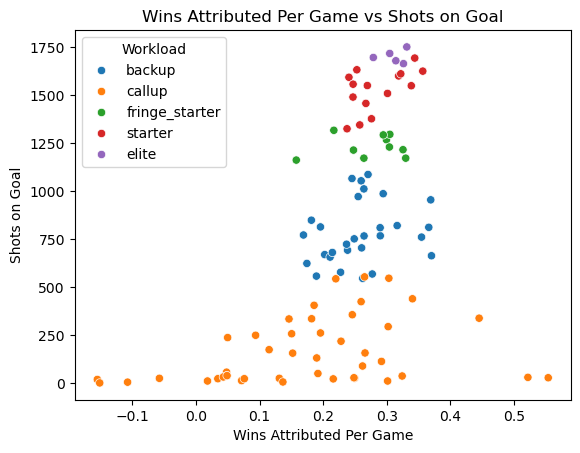

In [234]:
#what about shots on goal
sb.scatterplot(data=data,
               x=data['wins_attributed_per_game'],
               y=data[('shots_on_goal', 'all')],
               hue=data[('workload', 'all')])

plt.title('Wins Attributed Per Game vs Shots on Goal')
plt.xlabel('Wins Attributed Per Game')
plt.ylabel('Shots on Goal')
plt.legend(title='Workload')
plt.show()

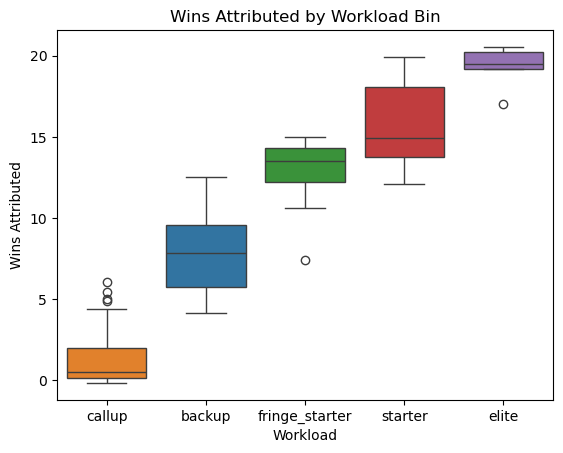

In [235]:
#chart for wins attributed by goalie by workload bin
sb.boxplot(data=data,
           x=data[('workload', 'all')],
            y=data['wins_attributed'],
            order=['callup', 'backup', 'fringe_starter', 'starter', 'elite'],
            hue=data[('workload', 'all')])
plt.title('Wins Attributed by Workload Bin')
plt.xlabel('Workload')
plt.ylabel('Wins Attributed')
plt.show()

Text(0, 0.5, 'Wins')

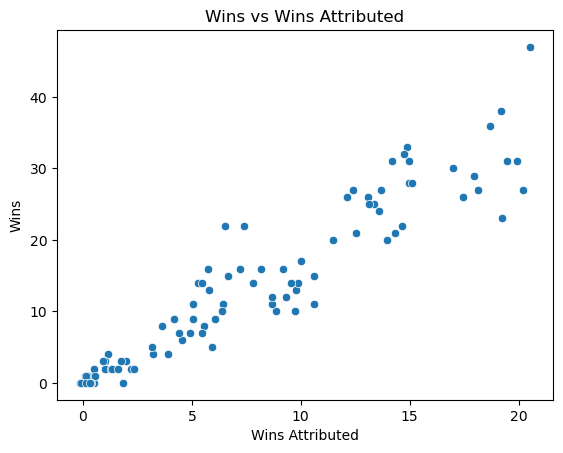

In [236]:
#graph wins by wins attributed
sb.scatterplot(data=data,
               x=data['wins_attributed'],
               y=data[('wins', 'all')])
plt.title('Wins vs Wins Attributed')
plt.xlabel('Wins Attributed')
plt.ylabel('Wins')

In [237]:
#what is average wins attributed per game by workload bin
grouped = data.groupby(('workload', 'all'))
grouped['wins_attributed_per_game'].mean()

(workload, all)
backup            0.258417
callup            0.174438
elite             0.310954
fringe_starter    0.274306
starter           0.284927
Name: wins_attributed_per_game, dtype: float64

In [238]:
#20 best goalies by wins attributed
data = data.sort_values(by=('wins_attributed'), ascending=False)
top_20 = data.head(20)
top_20

wins                         games_played  \
situation                          4on5  5on4  5on5   all other         4on5   
playerId name                team                                              
8476945  Connor Hellebuyck   WPG   47.0  47.0  47.0  47.0  47.0         63.0   
8478048  Igor Shesterkin     NYR   27.0  27.0  27.0  27.0  27.0         61.0   
8479406  Filip Gustavsson    MIN   31.0  31.0  31.0  31.0  31.0         58.0   
8478470  Sam Montembeault    MTL   31.0  31.0  31.0  31.0  31.0         62.0   
8480843  Lukas Dostal        ANA   23.0  23.0  23.0  23.0  23.0         54.0   
8476883  Andrei Vasilevskiy  TBL   38.0  38.0  38.0  38.0  38.0         63.0   
8479979  Jake Oettinger      DAL   36.0  36.0  36.0  36.0  36.0         58.0   
8478916  Joey Daccord        SEA   27.0  27.0  27.0  27.0  27.0         57.0   
8481692  Dustin Wolf         CGY   29.0  29.0  29.0  29.0  29.0         53.0   
8478872  Karel Vejmelka      UTA   26.0  26.0  26.0  26.0  26.0         58.0   
8478009  Ilya Sorokin        NYI   30.0  30.0  30.0  30.0  30.0         61.0   
8478406  Mackenzie Blackwood COL   28.0  28.0  28.0  28.0  28.0         56.0   
8475311  Darcy Kuemper       LAK   31.0  31.0  31.0  31.0  31.0         50.0   
8476412  Jordan Binnington   STL   28.0  28.0  28.0  28.0  28.0         56.0   
8475683  Sergei Bobrovsky    FLA   33.0  33.0  33.0  33.0  33.0         54.0   
8478499  Adin Hill           VGK   32.0  32.0  32.0  32.0  32.0         50.0   
8480280  Jeremy Swayman      BOS   22.0  22.0  22.0  22.0  22.0         58.0   
8475660  Cam Talbot          DET   21.0  21.0  21.0  21.0  21.0         47.0   
8480313  Logan Thompson      WSH   31.0  31.0  31.0  31.0  31.0         43.0   
8477424  Juuse Saros         NSH   20.0  20.0  20.0  20.0  20.0         58.0   

                                                           ... workload  \
situation                          5on4  5on5   all other  ...     5on5   
playerId name                team                          ...            
8476945  Connor Hellebuyck   WPG   63.0  63.0  63.0  63.0  ...      NaN   
8478048  Igor Shesterkin     NYR   61.0  61.0  61.0  61.0  ...      NaN   
8479406  Filip Gustavsson    MIN   58.0  58.0  58.0  58.0  ...      NaN   
8478470  Sam Montembeault    MTL   62.0  62.0  62.0  62.0  ...      NaN   
8480843  Lukas Dostal        ANA   54.0  54.0  54.0  54.0  ...      NaN   
8476883  Andrei Vasilevskiy  TBL   63.0  63.0  63.0  63.0  ...      NaN   
8479979  Jake Oettinger      DAL   58.0  58.0  58.0  58.0  ...      NaN   
8478916  Joey Daccord        SEA   57.0  57.0  57.0  57.0  ...      NaN   
8481692  Dustin Wolf         CGY   53.0  53.0  53.0  53.0  ...      NaN   
8478872  Karel Vejmelka      UTA   58.0  58.0  58.0  58.0  ...      NaN   
8478009  Ilya Sorokin        NYI   61.0  61.0  61.0  61.0  ...      NaN   
8478406  Mackenzie Blackwood COL   56.0  56.0  56.0  56.0  ...      NaN   
8475311  Darcy Kuemper       LAK   50.0  50.0  50.0  50.0  ...      NaN   
8476412  Jordan Binnington   STL   56.0  56.0  56.0  56.0  ...      NaN   
8475683  Sergei Bobrovsky    FLA   54.0  54.0  54.0  54.0  ...      NaN   
8478499  Adin Hill           VGK   50.0  50.0  50.0  50.0  ...      NaN   
8480280  Jeremy Swayman      BOS   58.0  58.0  58.0  58.0  ...      NaN   
8475660  Cam Talbot          DET   47.0  47.0  47.0  47.0  ...      NaN   
8480313  Logan Thompson      WSH   43.0  43.0  43.0  43.0  ...      NaN   
8477424  Juuse Saros         NSH   58.0  58.0  58.0  58.0  ...      NaN   

                                                        goals_attributed  \
situation                                     all other             5on5   
playerId name                team                                          
8476945  Connor Hellebuyck   WPG            elite   NaN        98.029943   
8478048  Igor Shesterkin     NYR            elite   NaN        89.863588   
8479406  Filip Gustavsson    MIN          starter   NaN        91.714889   
8478470  Sam

In [239]:
#top 20 workload count
top_20['workload', 'all'].value_counts()

(workload, all)
starter           11
elite              5
fringe_starter     4
Name: count, dtype: int64

In [240]:
#linear regression to predict wins based on stats
import statsmodels.api as sm
data = data.sort_index(axis=1, level=[0, 1])

x = data.loc[:, ('freeze', '4on5'):('unblocked_shot_attempts', 'other')]
for col in x.columns:
    if 'save_percentage' in col[0]:
        x = x.drop(columns=[col])

y = data.loc[:, ('wins', 'all')]

#combine and drop nas so the whole row is dropped if there is a missing value in either x or y
combined = pd.concat([x, y], axis=1).dropna()
x_clean = combined[x.columns]
y_clean = combined[y.name]

reg_model = sm.OLS(y_clean, x_clean).fit()
print(reg_model.rsquared_adj)
print(reg_model.summary())
#99.1% of the goalies win total can be explained by these stats

0.9910997056837418
                                 OLS Regression Results                                
Dep. Variable:        ('wins', 'all')   R-squared (uncentered):                   0.996
Model:                            OLS   Adj. R-squared (uncentered):              0.991
Method:                 Least Squares   F-statistic:                              209.5
Date:                Fri, 20 Mar 2026   Prob (F-statistic):                    1.01e-43
Time:                        21:53:20   Log-Likelihood:                         -156.23
No. Observations:                 103   AIC:                                      422.5
Df Residuals:                      48   BIC:                                      567.4
Df Model:                          55                                                  
Covariance Type:            nonrobust                                                  
                                    coef    std err          t      P>|t|      [0.025      0.975]
---

In [241]:
coefficients = pd.DataFrame(reg_model.params, columns=['coefficient'])
print("Top 10 Stats for Increasing Wins:")
print(coefficients.sort_values(ascending=True, by='coefficient').head(10))
print("Bottom 10 Stats for Increasing Wins:")
print(coefficients.sort_values(ascending=False, by='coefficient').head(10))

Top 10 Stats for Increasing Wins:
                        coefficient
freeze_5on4               -3.232391
freeze_other              -2.983756
freeze_5on5               -2.885486
freeze_4on5               -2.636111
rebounds_all              -0.814972
shots_on_goal_all         -0.695525
low_danger_shots_other    -0.535131
low_danger_goals_other    -0.463217
high_danger_shots_4on5    -0.462543
goals_allowed_other       -0.460149
Bottom 10 Stats for Increasing Wins:
                       coefficient
freeze_all                2.870624
rebounds_5on4             0.842197
rebounds_4on5             0.795086
rebounds_5on5             0.773224
rebounds_other            0.757236
shots_on_goal_4on5        0.741661
shots_on_goal_5on4        0.682452
shots_on_goal_5on5        0.681607
shots_on_goal_other       0.537238
high_danger_shots_all     0.444191


In [242]:
data.to_excel('final_goalie_data.xlsx')